<a href="https://colab.research.google.com/github/rmkenv/30daymap2025/blob/main/false%2B_milspec_wood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install opencv-python-headless


Loading test pattern: /content/milspec.png
Testing pattern: /content/milspec.png
Image dimensions: (1024, 1024, 3)

=== DETECTION RESULTS ===
False face detections: 3
False eye detections: 0
False smile detections: 162

=== PATTERN ANALYSIS ===
Edge density: 0.1505 (157858 edge pixels)
Contrast level: 40.08
High frequency energy: 209714

=== ADVERSARIAL EFFECTIVENESS ===
False positive score: 165
Complexity score: 228.78
Overall adversarial score: 393.78
✅ EXCELLENT: High false positive rate - very confusing to AI
✅ HIGH COMPLEXITY: Dense edge patterns good for disruption


/tmp/ipython-input-3229349248.py:135: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0, 256], alpha=0.7)


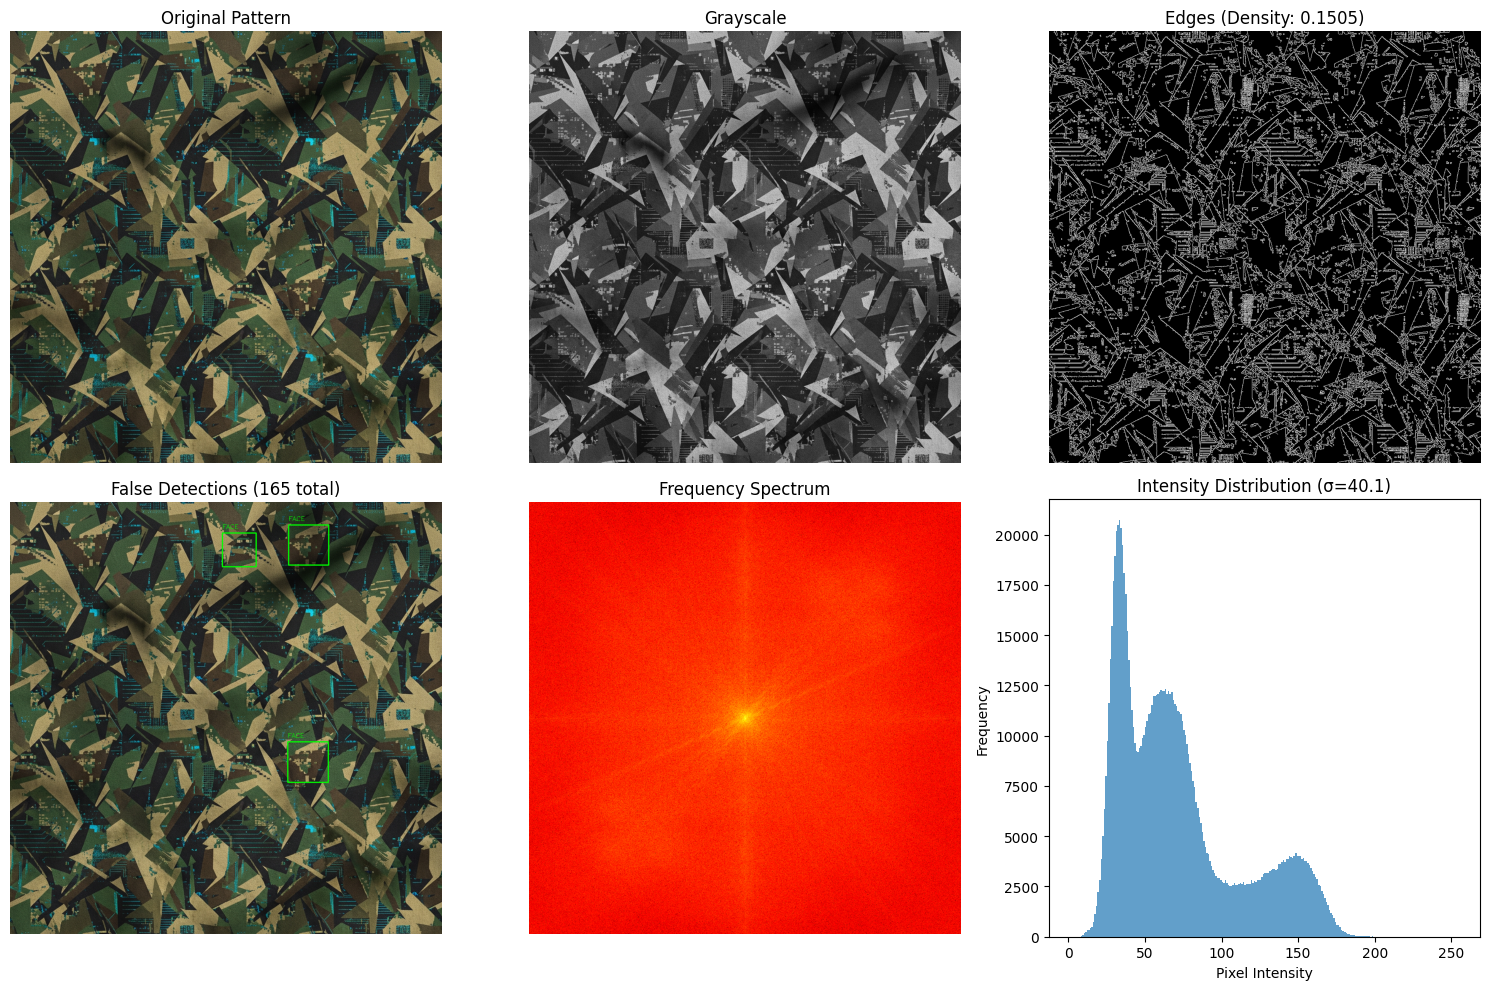


=== SUMMARY ===
Pattern tested successfully!
Replace the pattern file path in load_test_image() to test custom designs.


In [2]:
# Adversarial Pattern Testing Script (Headless Compatible)
import numpy as np
import matplotlib.pyplot as plt
import os

# Use cv2 from opencv-python-headless
try:
    import cv2
except ImportError:
    print("Please install opencv-python-headless (pip install opencv-python-headless) for server/headless environments.")
    raise

def load_test_image(filename=None):
    """
    Load a local test adversarial pattern. User provides path, or uses default.
    """
    if filename is None:
        filename = "/content/milspec.png"
    if os.path.exists(filename):
        print(f"Loading test pattern: {filename}")
        return filename
    else:
        print(f"Error: File not found at {filename}")
        print("Please check the file path or upload the image.")
        return None

def test_adversarial_pattern(image_path):
    """
    Test adversarial properties of a pattern.
    """
    if image_path is None:
        print("No image provided for testing.")
        return

    pattern = cv2.imread(image_path)
    if pattern is None:
        print(f"Error: Unable to load image from {image_path}")
        return

    print(f"Testing pattern: {image_path}")
    print(f"Image dimensions: {pattern.shape}")

    # Initialize detectors
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

    # Detection
    faces = face_cascade.detectMultiScale(pattern, scaleFactor=1.1, minNeighbors=3, minSize=(30, 30))
    eyes = eye_cascade.detectMultiScale(pattern, scaleFactor=1.1, minNeighbors=3, minSize=(10, 10))
    smiles = smile_cascade.detectMultiScale(pattern, scaleFactor=1.1, minNeighbors=3, minSize=(20, 20))

    print("\n=== DETECTION RESULTS ===")
    print(f"False face detections: {len(faces)}")
    print(f"False eye detections: {len(eyes)}")
    print(f"False smile detections: {len(smiles)}")

    gray = cv2.cvtColor(pattern, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edge_count = np.sum(edges > 0)
    edge_density = edge_count / (gray.shape[0] * gray.shape[1])
    contrast = gray.std()
    f_transform = np.fft.fft2(gray)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(np.abs(f_shift) + 1)
    high_freq_energy = np.sum(magnitude_spectrum > np.percentile(magnitude_spectrum, 80))

    print("\n=== PATTERN ANALYSIS ===")
    print(f"Edge density: {edge_density:.4f} ({edge_count} edge pixels)")
    print(f"Contrast level: {contrast:.2f}")
    print(f"High frequency energy: {high_freq_energy}")

    false_positive_score = len(faces) + len(eyes) + len(smiles)
    complexity_score = (edge_density * 100) + (contrast / 10) + (high_freq_energy / 1000)
    adversarial_score = false_positive_score + complexity_score

    print(f"\n=== ADVERSARIAL EFFECTIVENESS ===")
    print(f"False positive score: {false_positive_score}")
    print(f"Complexity score: {complexity_score:.2f}")
    print(f"Overall adversarial score: {adversarial_score:.2f}")

    if false_positive_score > 5:
        print("✅ EXCELLENT: High false positive rate - very confusing to AI")
    elif false_positive_score > 2:
        print("✅ GOOD: Moderate false positives - effective confusion")
    elif false_positive_score > 0:
        print("⚠️  FAIR: Some false positives - limited effectiveness")
    else:
        print("❌ POOR: No false positives - may not confuse AI effectively")

    if edge_density > 0.1:
        print("✅ HIGH COMPLEXITY: Dense edge patterns good for disruption")
    elif edge_density > 0.05:
        print("⚠️  MEDIUM COMPLEXITY: Moderate edge density")
    else:
        print("❌ LOW COMPLEXITY: May need more geometric detail")

    # Visualization
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(pattern, cv2.COLOR_BGR2RGB))
    plt.title('Original Pattern')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(gray, cmap='gray')
    plt.title('Grayscale')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(edges, cmap='gray')
    plt.title(f'Edges (Density: {edge_density:.4f})')
    plt.axis('off')

    detection_img = pattern.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(detection_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(detection_img, 'FACE', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    for (x, y, w, h) in eyes:
        cv2.rectangle(detection_img, (x, y), (x+w, y+h), (255, 0, 0), 1)
        cv2.putText(detection_img, 'EYE', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 1)

    plt.subplot(2, 3, 4)
    plt.imshow(cv2.cvtColor(detection_img, cv2.COLOR_BGR2RGB))
    plt.title(f'False Detections ({false_positive_score} total)')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(magnitude_spectrum, cmap='hot')
    plt.title('Frequency Spectrum')
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.hist(gray.ravel(), 256, [0, 256], alpha=0.7)
    plt.title(f'Intensity Distribution (σ={contrast:.1f})')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    return {
        'false_positives': false_positive_score,
        'edge_density': edge_density,
        'contrast': contrast,
        'adversarial_score': adversarial_score
    }

if __name__ == "__main__":
    test_image = load_test_image()  # Optionally, pass a different file path as argument
    results = test_adversarial_pattern(test_image)
    if results is not None:
        print("\n=== SUMMARY ===")
        print("Pattern tested successfully!")
        print("Replace the pattern file path in load_test_image() to test custom designs.")


In [3]:
!pip install adversarial-robustness-toolbox tensorflow matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.3 MB/s eta 0:00:00


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, CarliniL2Method
from art.estimators.classification import TensorFlowV2Classifier
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image


In [5]:
# Load ResNet50 model
model = ResNet50(weights='imagenet')

# Define TensorFlowV2Classifier wrapper for ART
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=1000,
    input_shape=(224, 224, 3),
    loss_object=tf.keras.losses.CategoricalCrossentropy()
)


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
def load_and_preprocess(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(np.expand_dims(x, axis=0))
    return x

def visualize(orig, adv, diff):
    plt.figure(figsize=(15, 4))
    titles = ["Original", "Adversarial", "Perturbation (amplified)"]
    images = [orig, adv, diff]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(titles[i])
        plt.imshow(images[i].astype('uint8'))
        plt.axis('off')
    plt.show()


Saving milspec.png to milspec (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


PGD - Batches: 0it [00:00, ?it/s]

C&W L_2:   0%|          | 0/1 [00:00<?, ?it/s]

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

===milspec (1).png: Class 'padlock'===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
[FGSM] Top Prediction: pencil_sharpener
Attack successful? ✅


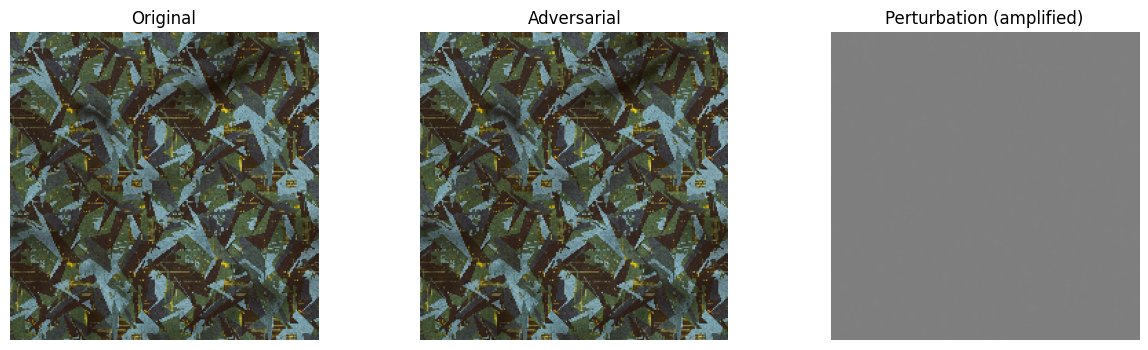

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
[PGD] Top Prediction: pencil_sharpener
Attack successful? ✅


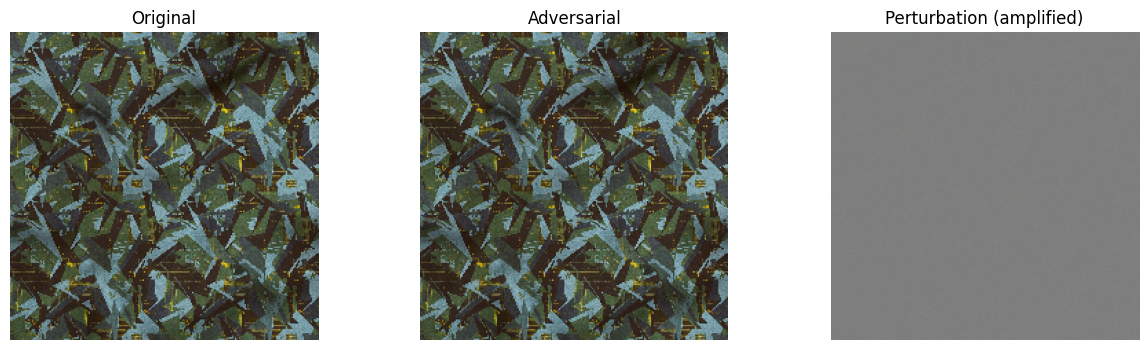

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
[CW] Top Prediction: padlock
Attack successful? ❌


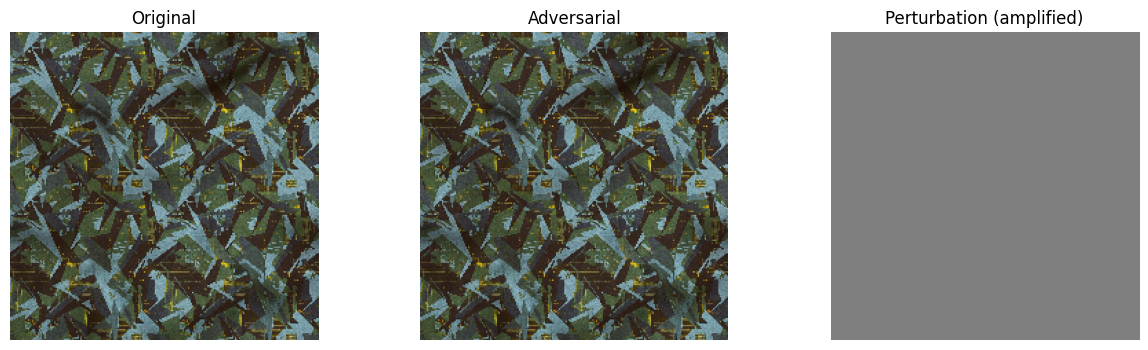

In [7]:
import os
from google.colab import files

# Upload multiple images if needed
uploaded = files.upload()
img_paths = list(uploaded.keys())

for img_path in img_paths:
    x = load_and_preprocess(img_path)
    y_pred = model.predict(x)

    true_class = np.argmax(y_pred)
    y_true = tf.keras.utils.to_categorical([true_class], num_classes=1000)

    # FGSM Attack
    fgsm = FastGradientMethod(estimator=classifier, eps=4/255)
    x_fgsm = fgsm.generate(x=x)

    # PGD Attack
    pgd = ProjectedGradientDescent(estimator=classifier, eps=8/255, eps_step=2/255, max_iter=40)
    x_pgd = pgd.generate(x=x)

    # CW Attack (Carlini & Wagner L2)
    cw = CarliniL2Method(classifier=classifier, confidence=0.0, max_iter=10)
    x_cw = cw.generate(x=x)

    # Evaluate and visualize results
    adv_examples = {'FGSM': x_fgsm, 'PGD': x_pgd, 'CW': x_cw}
    print(f"\n==={img_path}: Class '{decode_predictions(y_pred, top=1)[0][0][1]}'===")

    for attack, adv_x in adv_examples.items():
        adv_pred = model.predict(adv_x)
        adv_class = np.argmax(adv_pred)
        adv_label = decode_predictions(adv_pred, top=1)[0][0][1]

        print(f"[{attack}] Top Prediction: {adv_label}")
        is_success = adv_class != true_class
        print(f"Attack successful? {'✅' if is_success else '❌'}")

        # Visualization
        orig_img = image.array_to_img(x[0])
        adv_img = image.array_to_img(adv_x[0])
        diff = np.clip((adv_x[0] - x[0]) * 40 + 127, 0, 255)  # Amplify perturbation for display
        visualize(np.array(orig_img), np.array(adv_img), diff)


In [8]:
#Optional batch stats for multi images
success_fgsm, success_pgd, success_cw = 0, 0, 0

for img_path in img_paths:
    # ... [same as above]
    if np.argmax(model.predict(x_fgsm)) != true_class:
        success_fgsm += 1
    if np.argmax(model.predict(x_pgd)) != true_class:
        success_pgd += 1
    if np.argmax(model.predict(x_cw)) != true_class:
        success_cw += 1

n = len(img_paths)
print(f"FGSM Success Rate: {success_fgsm/n:.2%}")
print(f"PGD Success Rate: {success_pgd/n:.2%}")
print(f"CW Success Rate: {success_cw/n:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
FGSM Success Rate: 100.00%
PGD Success Rate: 100.00%
CW Success Rate: 0.00%
